In [3]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical

In [4]:
# ===============================
# 2. LOAD DATA (Kaggle Path)
# ===============================

train_df = pd.read_csv('C:/Users/Ranuga/Downloads/archive (3)/sign_mnist_train/sign_mnist_train.csv')
test_df  = pd.read_csv('C:/Users/Ranuga/Downloads/archive (3)/sign_mnist_test/sign_mnist_test.csv')

y_train = train_df['label'].values
y_test  = test_df['label'].values

x_train = train_df.drop('label', axis=1).values
x_test  = test_df.drop('label', axis=1).values

print(f"Original shapes: Train={x_train.shape}, Test={x_test.shape}")

Original shapes: Train=(27455, 784), Test=(7172, 784)


In [5]:

# ===============================
# 3. PREPROCESS DATA (CRITICAL)
# ===============================

# Normalizing
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

num_classes = 26 
y_cat_train = to_categorical(y_train, num_classes)
y_cat_test  = to_categorical(y_test, num_classes)

print("\nAfter preprocessing:")
print(f"X shape: {x_train.shape} | Y shape: {y_cat_train.shape}")


After preprocessing:
X shape: (27455, 28, 28, 1) | Y shape: (27455, 26)


In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ===============================
# 4. BUILD CNN MODEL
# ===============================
model = Sequential()


model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=(28,28,1), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25)) #Prevents overfitting

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())


model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(26, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\Ranuga\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 227,482 (888.60 KB)

 Trainable params: 227,290 (887.85 KB)

 Non-trainable params: 192 (768.00 B)

In [22]:
# ===============================
# 5. TRAIN MODEL
# ===============================
history = model.fit(
    x_train, y_cat_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.4334 - loss: 1.9984 - val_accuracy: 0.9455 - val_loss: 0.1987
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8847 - loss: 0.3332 - val_accuracy: 0.9856 - val_loss: 0.0557
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9485 - loss: 0.1536 - val_accuracy: 0.9947 - val_loss: 0.0204
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.9606 - loss: 0.1158 - val_accuracy: 0.9991 - val_loss: 0.0046
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.9685 - loss: 0.0891 - val_accuracy: 1.0000 - val_loss: 5.0288e-04
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.9749 - loss: 0.0727 - val_accuracy: 0.9954 - val_loss: 0.0162
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9800 - loss: 0.0616 - val_accuracy: 0.9933 - val_loss: 0.0227
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9768 - loss: 0.070

In [13]:
# ===============================
# 6. EVALUATE MODEL
# ===============================
test_loss, test_acc = model.evaluate(x_test, y_cat_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9429 - loss: 0.3428

Test Accuracy: 0.9456


In [11]:
# ===============================
# 7. PREDICTIONS
# ===============================
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [12]:
# ===============================
# 8. CONFUSION MATRIX & REPORT
# ===============================
from sklearn.metrics import confusion_matrix, classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       432
           2       0.97      1.00      0.98       310
           3       1.00      1.00      1.00       245
           4       0.98      1.00      0.99       498
           5       1.00      1.00      1.00       247
           6       0.82      0.82      0.82       348
           7       0.99      0.86      0.92       436
           8       0.92      0.92      0.92       288
          10       0.86      1.00      0.92       331
          11       1.00      1.00      1.00       209
          12       0.90      0.95      0.92       394
          13       1.00      0.79      0.88       291
          14       0.98      0.92      0.95       246
          15       0.94      1.00      0.97       347
          16       1.00      0.97      0.98       164
          17       1.00      0.85      0.92       144
   

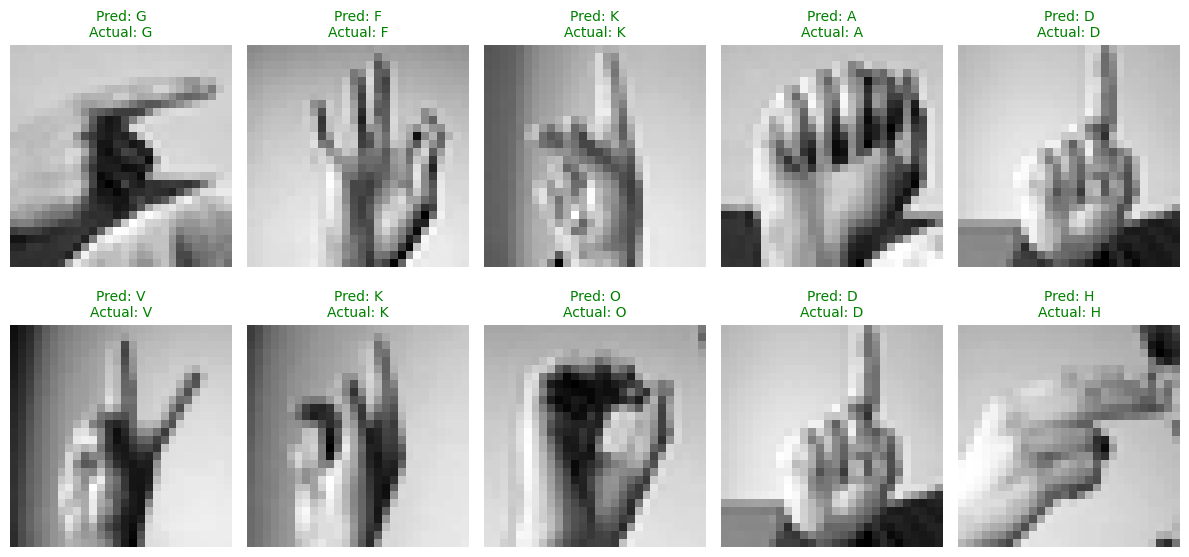

In [26]:
# ===============================
# 9. VISUALIZE SAMPLE PREDICTIONS
# ===============================

plt.figure(figsize=(12, 6))

alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    
    predicted_idx = y_pred[i]
    actual_idx = y_test[i]
    
    pred_letter = alphabet[predicted_idx]
    actual_letter = alphabet[actual_idx]
    
    title_color = 'green' if predicted_idx == actual_idx else 'red'
    
    plt.title(f"Pred: {pred_letter}\nActual: {actual_letter}", color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

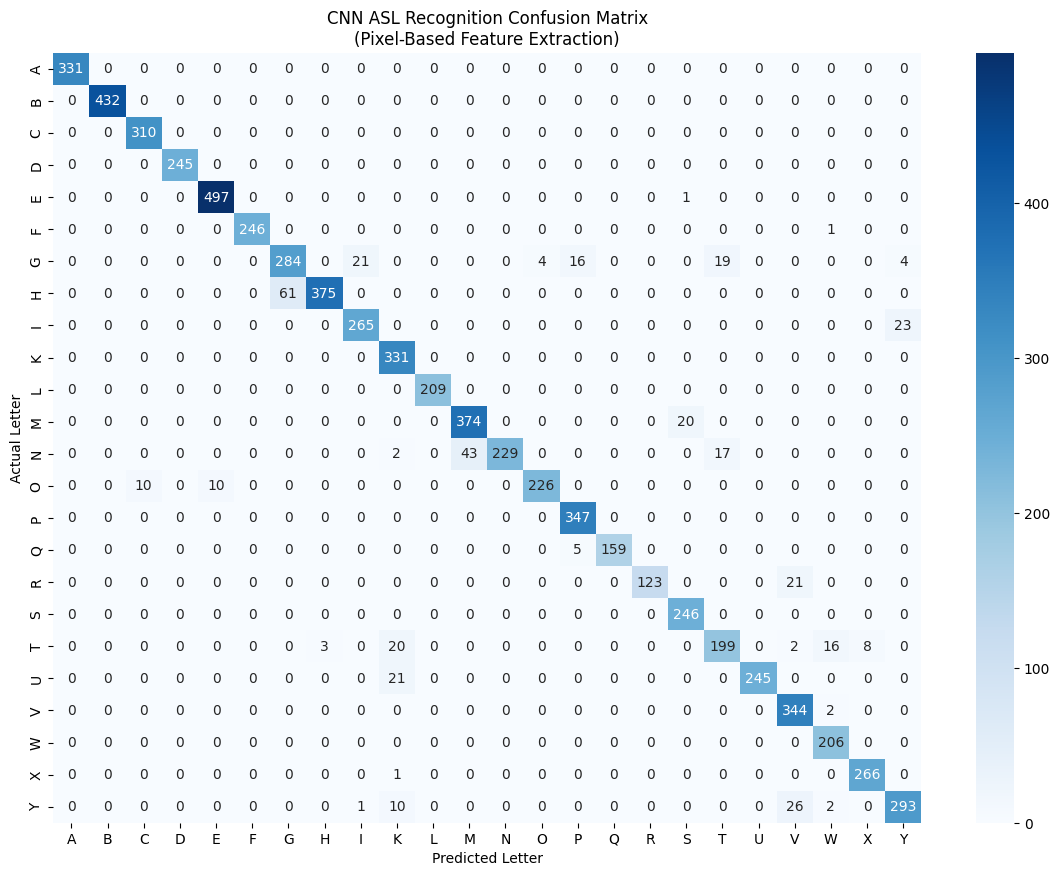

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# 2. PREDICTIONS
# CNN processes raw pixels to identify patterns like skin folds
y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# 4. CONFUSION MATRIX VISUALIZATION
# This matrix proves where pixel-based processing succeeds or fails [cite: 42, 98]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[alphabet[i] for i in np.unique(y_test)], 
            yticklabels=[alphabet[i] for i in np.unique(y_test)])

plt.title("CNN ASL Recognition Confusion Matrix\n(Pixel-Based Feature Extraction)")
plt.ylabel('Actual Letter')
plt.xlabel('Predicted Letter')
plt.show()

In [27]:
model.save('sign_mnist_cnn.keras')
print("Model saved as sign_mnist_cnn.keras")

Model saved as sign_mnist_cnn.keras


In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. LOAD THE TRAINED MODEL
model = load_model('sign_mnist_cnn.keras')
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

# 2. INITIALIZE VIDEO CAPTURE
cap = cv2.VideoCapture(0)

print("Starting Webcam... Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Flip the frame to be like a mirror
    frame = cv2.flip(frame, 1)

    # 3. DEFINE THE REGION OF INTEREST (ROI)
    # We use a square box where the user places their hand
    x1, y1, x2, y2 = 100, 100, 400, 400
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    # Extract and Preprocess the ROI
    roi = frame[y1:y2, x1:x2]
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28)) # Match model input size
    
    # Normalize and Reshape for the CNN
    # Input shape must be (1, 28, 28, 1) -> (Batch, Height, Width, Channels)
    pixel_data = resized.astype("float32") / 255.0
    pixel_data = pixel_data.reshape(1, 28, 28, 1)

    # 4. PREDICTION
    prediction = model.predict(pixel_data, verbose=0)
    pred_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    predicted_letter = alphabet[pred_idx]

    # 5. DISPLAY RESULTS
    # Only show prediction if confidence is high enough (e.g., > 70%)
    display_text = f"Letter: {predicted_letter} ({confidence*100:.1f}%)"
    
    cv2.putText(frame, display_text, (100, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    # Show the frames
    cv2.imshow("ASL Recognition (Press 'q' to exit)", frame)
    cv2.imshow("Model Input (28x28)", resized)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Starting Webcam... Press 'q' to quit.


In [4]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. LOAD MODEL & CONFIG
model = load_model('sign_mnist_cnn.keras')
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
background = None  # To store the static background frame
accumulated_weight = 0.5

def segment_hand(frame, threshold=25):
    global background
    # Find the absolute difference between background and current frame
    diff = cv2.absdiff(background.astype("uint8"), frame)

    # Threshold the diff image so that we get the foreground
    _ , thresholded = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)

    # Get the contours in the thresholded image
    contours, _ = cv2.findContours(thresholded.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None
    else:
        # The largest contour in the ROI is the hand
        segmented = max(contours, key=cv2.contourArea)
        return (thresholded, segmented)

# 2. INITIALIZE CAMERA
cap = cv2.VideoCapture(0)

print("1. Clear the frame and press 'b' to capture the background.")
print("2. Place hand in the box to begin detection.")

while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.flip(frame, 1)
    clone = frame.copy()

    # ROI Coordinates
    x1, y1, x2, y2 = 100, 100, 350, 350
    roi = frame[y1:y2, x1:x2]
    gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray_roi = cv2.GaussianBlur(gray_roi, (7, 7), 0)

    # 3. BACKGROUND CAPTURE LOGIC
    keypress = cv2.waitKey(1) & 0xFF
    if keypress == ord("b"):
        background = gray_roi.copy().astype("float")
        print("Background Captured!")

    # 4. SEGMENTATION & PREDICTION
    if background is not None:
        hand = segment_hand(gray_roi)
        
        if hand is not None:
            thresholded, segmented = hand
            
            # Show the Binary Threshold window (matches your 2nd image)
            cv2.imshow("Thesholded (Solid Silhouette)", thresholded)

            # Prepare for CNN
            input_img = cv2.resize(thresholded, (28, 28))
            input_img = input_img.reshape(1, 28, 28, 1).astype("float32") / 255.0

            # Prediction
            prediction = model.predict(input_img, verbose=0)
            pred_idx = np.argmax(prediction)
            
            cv2.putText(clone, f"Sign: {alphabet[pred_idx]}", (x1, y1-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # 5. DRAW GUI
    cv2.rectangle(clone, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.imshow("Video Feed", clone)

    if keypress == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


1. Clear the frame and press 'b' to capture the background.
2. Place hand in the box to begin detection.
Background Captured!
